---------------------------------------------------------------------------
📍 CLUSTER 1069
     🔍 Full disguise... 
        ✂️ Data/Syntetic/1069/route_loc1069_4.json ✔️
        ✂️ Data/Syntetic/1069/route_loc1069_2.json ✔️
        ✂️ Data/Syntetic/1069/route_loc1069_3.json ✔️
        ✂️ Data/Syntetic/1069/route_loc1069_0.json ✔️
        ✂️ Data/Syntetic/1069/route_loc1069_1.json ✔️
     🔍 Done. (14.5s)

     🔫 Attack 2... 
[<DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac5930>, <DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac7760>, <DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac5cc0>, <DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac5870>, <DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac77c0>, <DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x1

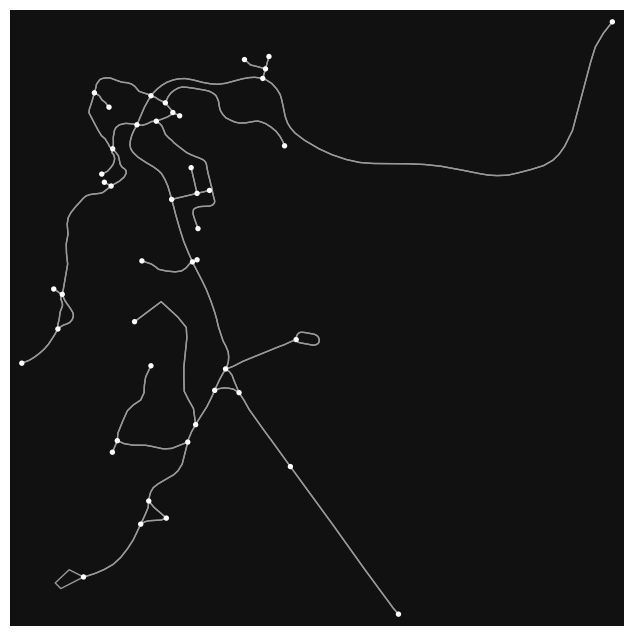

/Users/marco/projects/stravaGANte/Attack2/EPZSearch.py:534: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, ax=ax, label='Sum of Positive Differences')


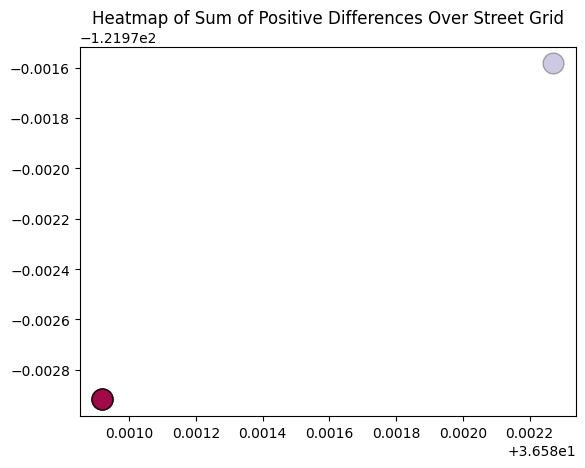

    🏁 Done. 0 possible EPZs found. (3.4s)

---------------------------------------------------------------------------
📍 CLUSTER 1855
     🔍 Full disguise... 
        ✂️ Data/Syntetic/1855/route_loc1855_1.json ✔️
        ✂️ Data/Syntetic/1855/route_loc1855_0.json ✔️
        ✂️ Data/Syntetic/1855/route_loc1855_3.json ✔️
        ✂️ Data/Syntetic/1855/route_loc1855_2.json ✔️
        ✂️ Data/Syntetic/1855/route_loc1855_4.json ✔️
     🔍 Done. (2.9s)

     🔫 Attack 2... 
[<DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac7ca0>, <DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac4fa0>, <DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac7790>, <DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac5d20>, <DataRepresentation.DataRepresentation.UTMDataRepresentation.UTMEndpoint object at 0x117ac5ea0>, <DataRepresentation.DataRepresentation.UTMDa

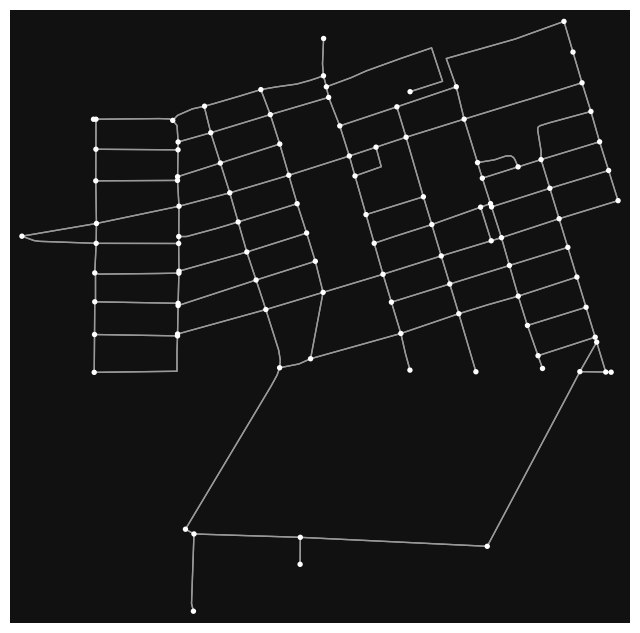

/Users/marco/projects/stravaGANte/Attack2/EPZSearch.py:534: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, ax=ax, label='Sum of Positive Differences')


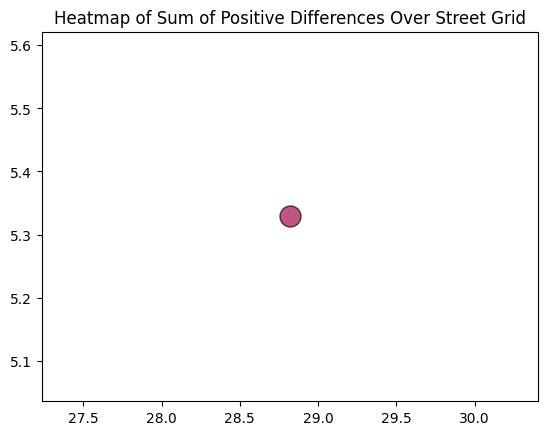

epz circle (np.float64(-11580420.272168947), np.float64(3542828.198983213))
(30.3051, -104.02868527016913)
Estimated number of clusters: 2


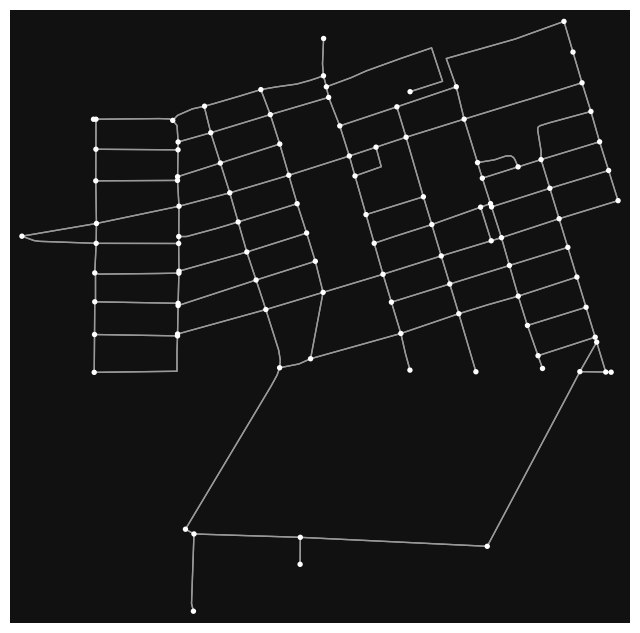

/Users/marco/projects/stravaGANte/Attack2/EPZSearch.py:534: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, ax=ax, label='Sum of Positive Differences')


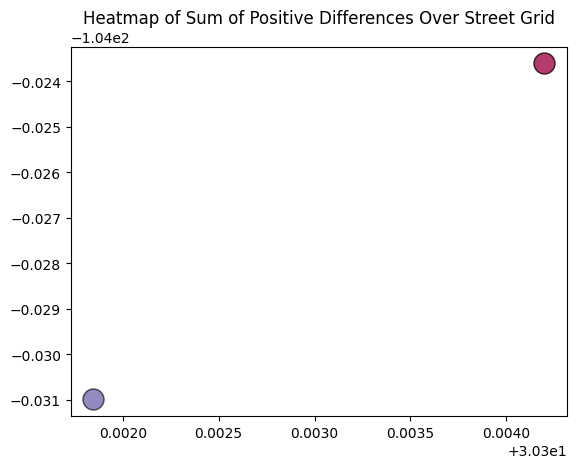

    🏁 Done. 5 possible EPZs found. (3.0s)



TypeError: list indices must be integers or slices, not dict

In [2]:
def addPolylineToPlot(plt, coordinateList, label=None):
    xs, ys = zip(*coordinateList)
    plt.plot(xs[0], ys[0], marker='o', color='g', ms=5)
    if label is None:
        plt.plot(xs ,ys)
    else:
        plt.plot(xs ,ys, label=label)
    plt.plot(xs[-1], ys[-1], marker='x', color='r', ms=5)


def plotUserActivity(userId="39260108"):        
    plt.figure()
    user = initializeUser(userId)
    for activity in user.activityList:
        activity.addActivityToPlot(plt)
    plt.legend(loc="upper left")
    plt.show() 


def fullDisguiseOfActivityCluster(activityClusterPath, activityClusterId = None):
    activityCluster = ActivityCluster.ActivityCluster.initializeActivityClusterFromJson(activityClusterPath, activityClusterId)
    geocentricData = DataRepresentationFactory.GeocentricDataRepresentationFactory().create_data_representation()
    sphericalData = DataRepresentationFactory.SphericalDataRepresentationFactory().create_data_representation()
    cloackedCenter = dataRepresentation.generateCloackedCenter(activityCluster.center, activityCluster.radius)
    activityCluster.updateActivityClusterCenterInJson({'cloackedCenter': cloackedCenter})
    for activityPath in activityCluster.activityPathList:
        print(f"        ✂️ {activityPath}", end='')
        with open(activityPath, 'r') as f:
            activity_data = json.load(f)

        map_data = activity_data.get('map', {})
        required_fields = ["EPZ", "EPZ+Fuzz", "CloackedEPZ", "CloackedEPZ+Fuzz", "GeocentricEPZ", "GeocentricEPZ+Fuzz", "GeocentricCloackedEPZ", "GeocentricCloackedEPZ+Fuzz"]

        if all(field in map_data and map_data[field] for field in required_fields) and not update:
            print(" 💾")
        else:
            activity = Activity.Activity.initActivityFromPath(activityPath)
            activity.completeDisguiseActivityInCluster(activityCluster.center, 800, activityCluster.cloackedCenter, sphericalData, geocentricData)
            print(" ✔️")
    
    return activityCluster


def firstAttack(activityPathList, dataRepresentation, appInfo, attackType):
    epzsa = EPZSearch.EPZSearch(dataRepresentation, activityPathList, appInfo, attackType)
    epzsa.initializeAttack()
    print(f"        🎯 All possible EPZ: {len(epzsa.possibleEPZs)}")
    epzsa.deleteEPZintersectingActivity()
    print(f"        🎯 Reduced EPZ: {len(epzsa.possibleEPZs)}")
    epzsa.groupCloseEPZs()
    print(f"        🎯 Group close EPZ: {len(epzsa.possibleEPZs)}")
    epzsa.deleteInformationlessEPZ()
    print(f"        🎯 Final set EPZ: {len(epzsa.possibleEPZs)}")
    epzsa.convertInLatLon()
    return epzsa.possibleEPZs


def secondAttack(activityCluster):
    epzSearch = EPZSearch2.EPZSearch(activityCluster)

    tau_converged = 10
    tau_disjoint = 1600
    epz_circles = epzSearch.epz_identification(tau_converged, tau_disjoint)

    print(f"        🎯 All possible EPZ: {len(epz_circles)} (center, radius)")
    
    for center, radius, _ in epz_circles:
        c = dataRepresentation.transformToLatLon(*center)
        print(f"            Center: ({round(c[0], 4)}, {round(c[1], 4)}), Radius: {round(radius, 2)} m")
    
    return epzSearch.retriveSensitiveLocation(epz_circles[0]), epzSearch.retriveSensitiveLocationThroughClusters(epz_circles[0])

################################################################################################################
##################################################### MAIN #####################################################
################################################################################################################

global appInfo
appInfo = ApplicationInfo.ApplicationInfo("Strava")
# attackType = "EPZ+Fuzz"
attackType = "EPZ"
dataRepresentation = DataRepresentationFactory.GeocentricDataRepresentationFactory().create_data_representation()
# dataRepresentation = DataRepresentationFactory.SphericalDataRepresentationFactory().create_data_representation(attackType)

for cluster in existing_clusters:
    cluster_num = cluster.strip("Data/Syntetic/").strip("/ActivityClusterList.json")
    print(f"---------------------------------------------------------------------------\n📍 CLUSTER {cluster_num}")
    now = time.time()
    print("     🔍 Full disguise... ")
    activityCluster = fullDisguiseOfActivityCluster(cluster)
    print(f"     🔍 Done. ({time.time()-now:.1f}s)\n")

    # now = time.time()
    # print("     💣 Attack 1... ")
    # possibleEPZs = firstAttack(activityCluster.activityPathList, dataRepresentation, appInfo, attackType)
    # print(f"    🏁 Done. {len(possibleEPZs)} possible EPZs found. ({time.time()-now:.1f}s)\n")

    now = time.time()
    print("     🔫 Attack 2... ")
    possibleEPZs, _ = secondAttack(activityCluster)
    print(f"    🏁 Done. {len(possibleEPZs) if possibleEPZs is not None else 0} possible EPZs found. ({time.time()-now:.1f}s)\n")

    if possibleEPZs is not None:
        listEPZ = sorted(list(possibleEPZs), key= lambda x: -possibleEPZs[x])

        now = time.time()
        for possibleEPZ in listEPZ[:3]:
            print(possibleEPZ, "numerosità:", possibleEPZs[possibleEPZ])
        
        fig, ax = plt.subplots()

        colors = list(mcolors.CSS4_COLORS.keys())
        for index, possibleEPZ in enumerate(listEPZ[:3]):
            possibleEPZ.addCircleToPlot(ax, addColor=colors[19+index], addLabel = possibleEPZs[possibleEPZ])
        plt.plot()


        for activityPath in activityCluster.activityPathList:
            activity = Activity.Activity.initActivityFromPath(activityPath)
            coordsList = activity.decodePolyline() #attackType)
            
            if dataRepresentation.__class__.__name__ == "GeocentricDataRepresentation":
                coordsList = dataRepresentation.convertCoordsListIntoRepresentation(coordsList)
                coordsList = dataRepresentation.convertCoordsListIntoLatLon(coordsList)
                addPolylineToPlot(ax, coordsList, attackType+" - DoubleTransformed")
            else:
                addPolylineToPlot(ax, coordsList, attackType)
            
        ax.plot()
        folderPath = 'images/'+datetime.datetime.now().strftime("%Y-%m-%d")+"/"
        if not os.path.exists(os.path.dirname(folderPath)):
            os.makedirs(os.path.dirname(folderPath))
        figName=folderPath+'epzPlotted'+datetime.datetime.now().strftime("%H-%M-%S")+'.png'
        plt.title(f"{dataRepresentation.__class__.__name__} \n Intersection Threshold = {appInfo.IntersectionThreshold}, Distance Threshold = {appInfo.DistanceThreshold} \n Confidence Threshold = {appInfo.ConfidenceThreshold}, MinDistance Threshold = {appInfo.MinDistanceThreshold} ")
        plt.legend(loc="upper right")
        plt.show()
        # fig.savefig(figName)
        print(f"     📸 Plot time: {time.time()-now:.1f}s")

        # Additional zoomed plot
        fig, ax = plt.subplots()
        for activityPath in activityCluster.activityPathList:
            activity = Activity.Activity.initActivityFromPath(activityPath)
            coordsList = activity.decodePolyline() #attackType)
            
            if dataRepresentation.__class__.__name__ == "GeocentricDataRepresentation":
                coordsList = dataRepresentation.convertCoordsListIntoRepresentation(coordsList)
                coordsList = dataRepresentation.convertCoordsListIntoLatLon(coordsList)
                addPolylineToPlot(ax, coordsList, attackType+" - DoubleTransformed")
            else:
                addPolylineToPlot(ax, coordsList, attackType)
        
        # Get the starting point of the first activity
        start_point = coordsList[0]
        ax.set_xlim(start_point[0] - 0.01, start_point[0] + 0.01)  # Approx 1km radius
        ax.set_ylim(start_point[1] - 0.01, start_point[1] + 0.01)  # Approx 1km radius

        ax.plot()
        figName=folderPath+'epzPlotted_zoomed'+datetime.datetime.now().strftime("%H-%M-%S")+'.png'
        plt.title(f"{dataRepresentation.__class__.__name__} \n Intersection Threshold = {appInfo.IntersectionThreshold}, Distance Threshold = {appInfo.DistanceThreshold} \n Confidence Threshold = {appInfo.ConfidenceThreshold}, MinDistance Threshold = {appInfo.MinDistanceThreshold} \n Zoomed 1km Radius")
        plt.legend(loc="upper right")
        plt.show()
        # fig.savefig(figName)
        print(f"     📸 Zoomed plot time: {time.time()-now:.1f}s")


